<a href="https://colab.research.google.com/github/tallapragadaananya-a11y/ML-2-1-Skill1/blob/main/Week%202/Spotify_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (500, 14)

Columns:
['Artist Name', 'Sex', 'Country of Origin', 'Primary Language', 'Primary Genre', ' Artist Type', 'Debut Year', 'Total Streams (in millions)', 'Lead Streams (in millions)', 'Feature Streams (in millions)', 'Solo Streams (in millions)', '% of Solo Streams', 'Collaborative Streams (in millions)', '% of Collaborative Streams']

First 5 rows:
     Artist Name     Sex Country of Origin Primary Language Primary Genre  \
0          Drake    Male            Canada          English       Hip-Hop   
1   Taylor Swift  Female     United States          English           Pop   
2      Bad Bunny    Male     United States          Spanish     Reggaeton   
3     The Weeknd    Male            Canada          English           R&B   
4  Justin Bieber    Male            Canada          English           Pop   

   Artist Type  Debut Year  Total Streams (in millions)  \
0         Solo        2006                     137492.1   
1         Solo        2006                  

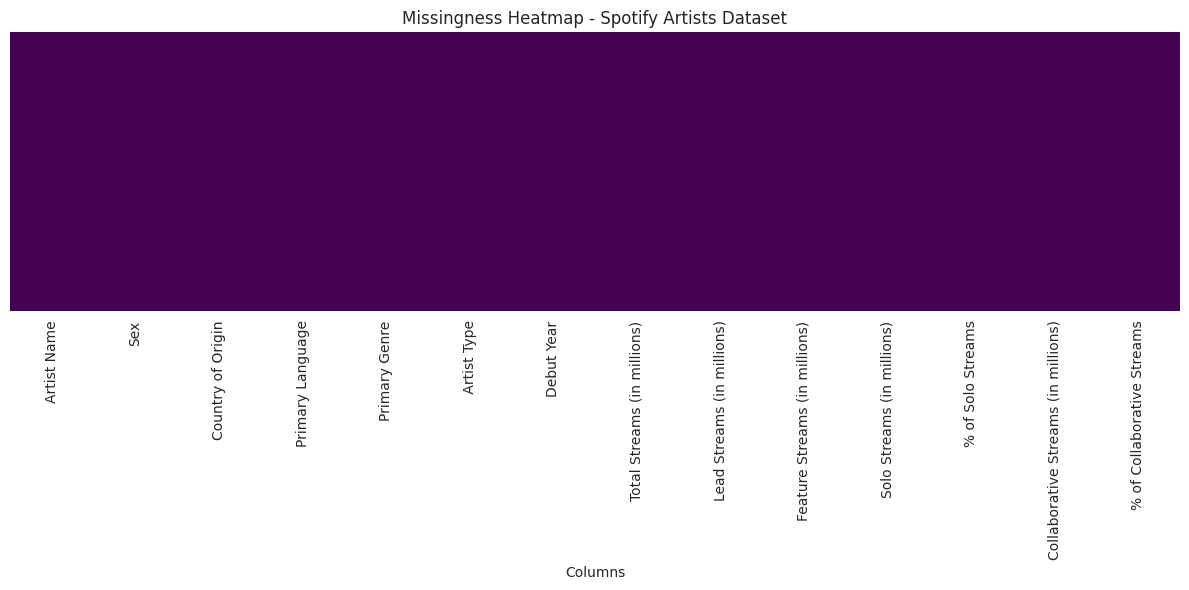

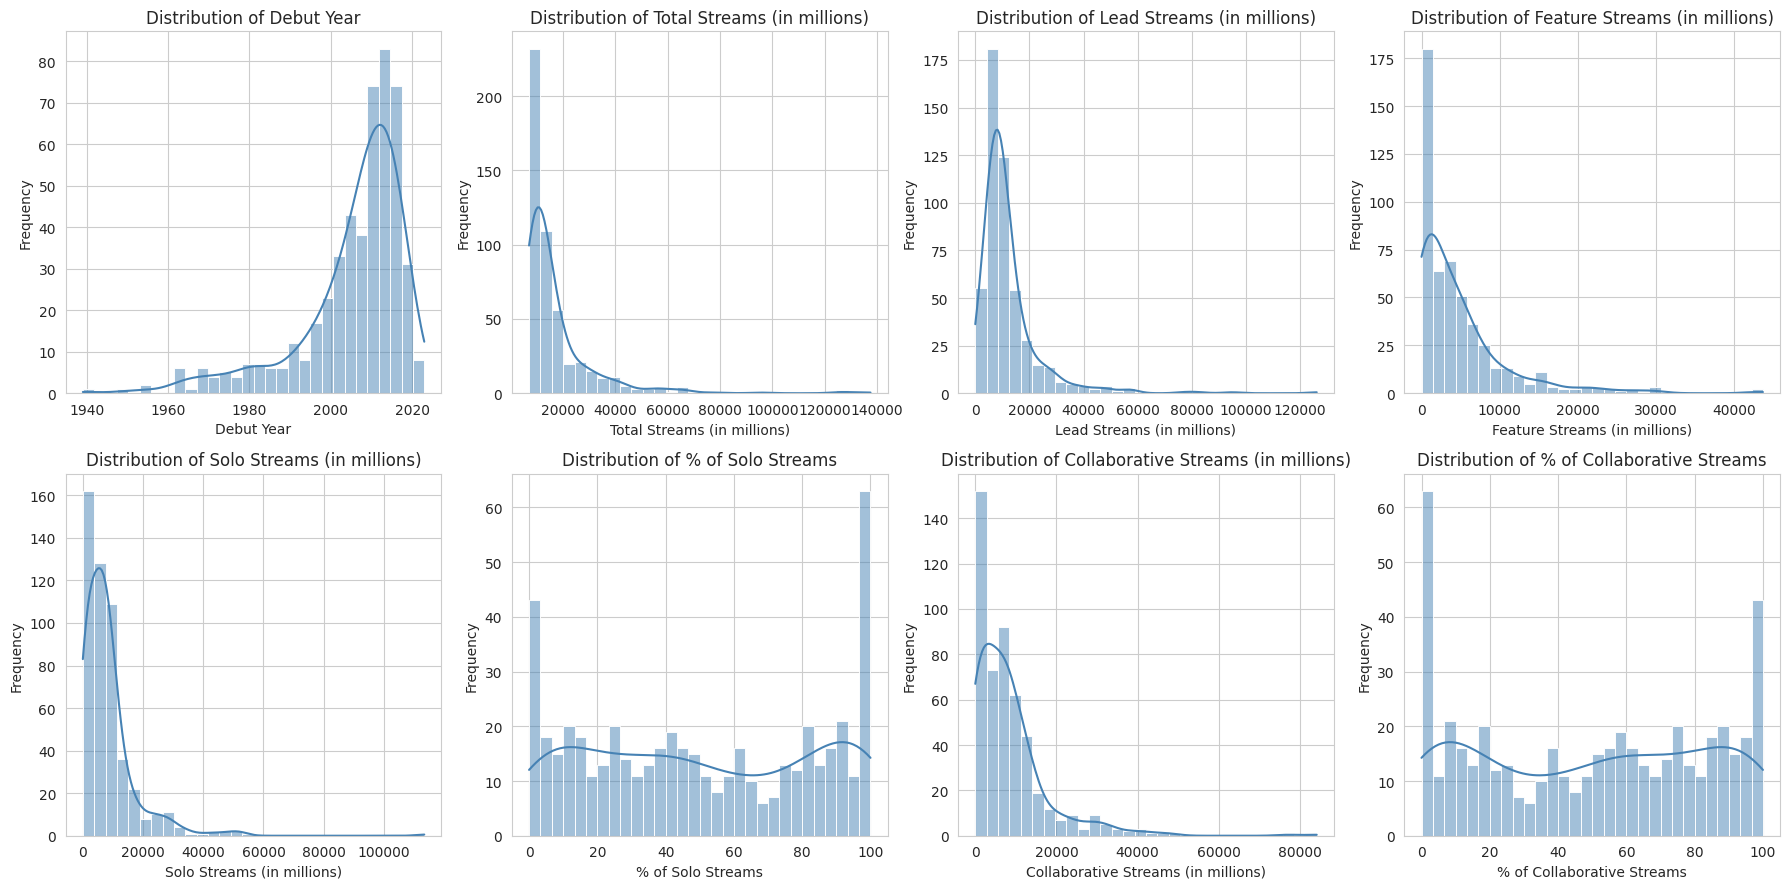

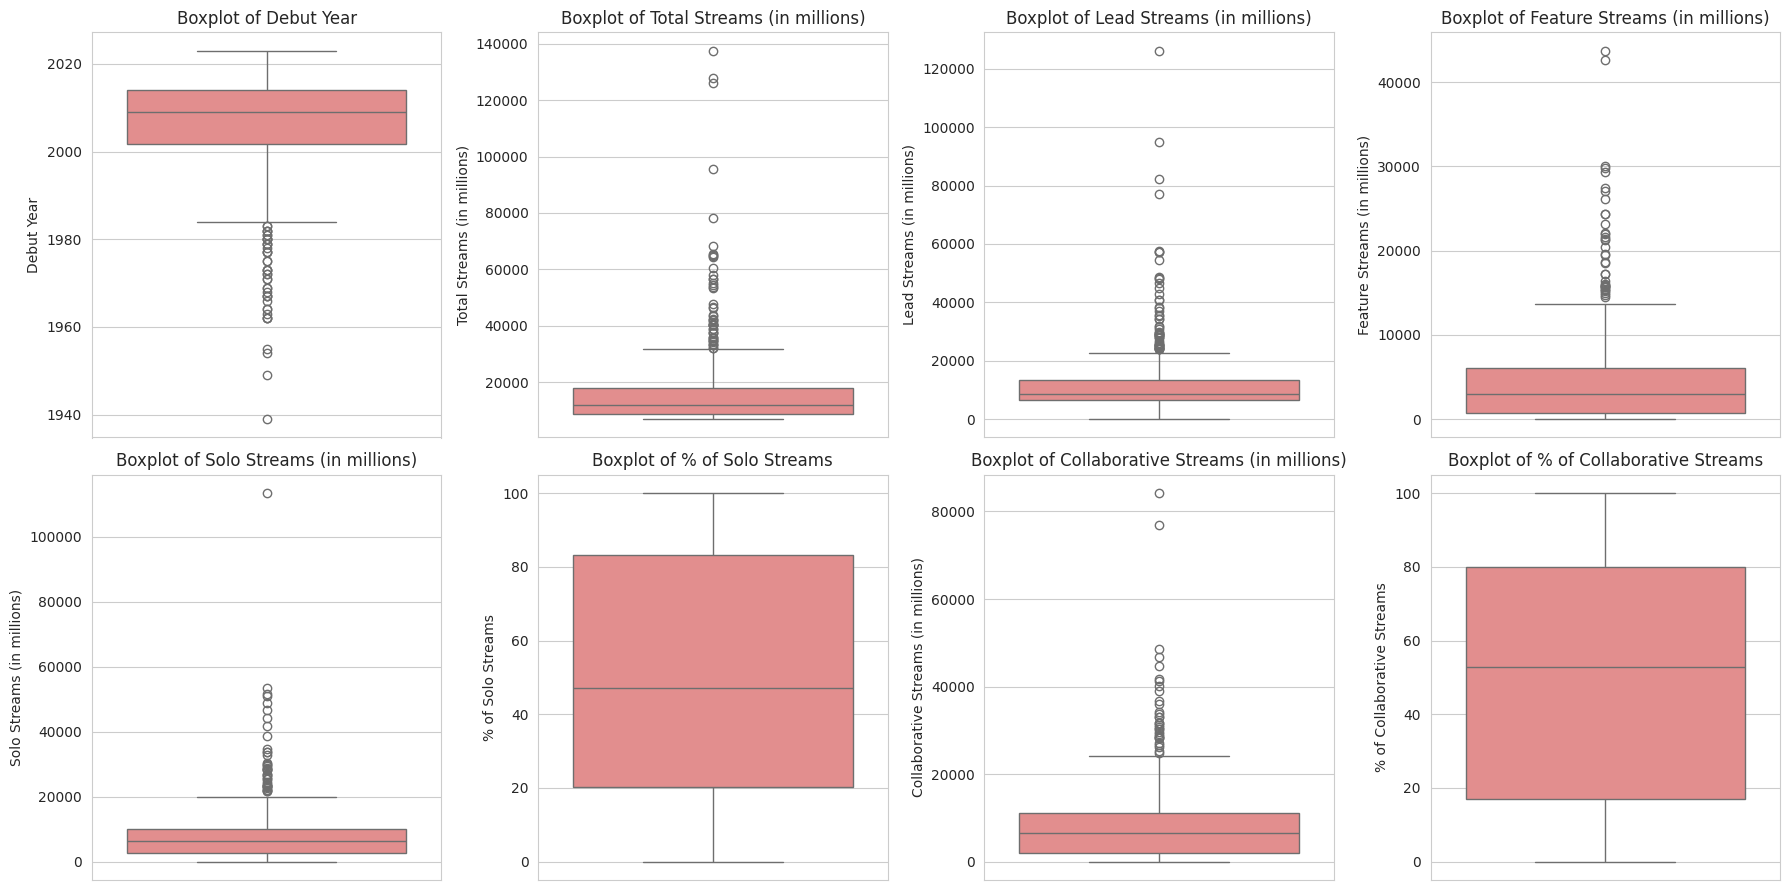

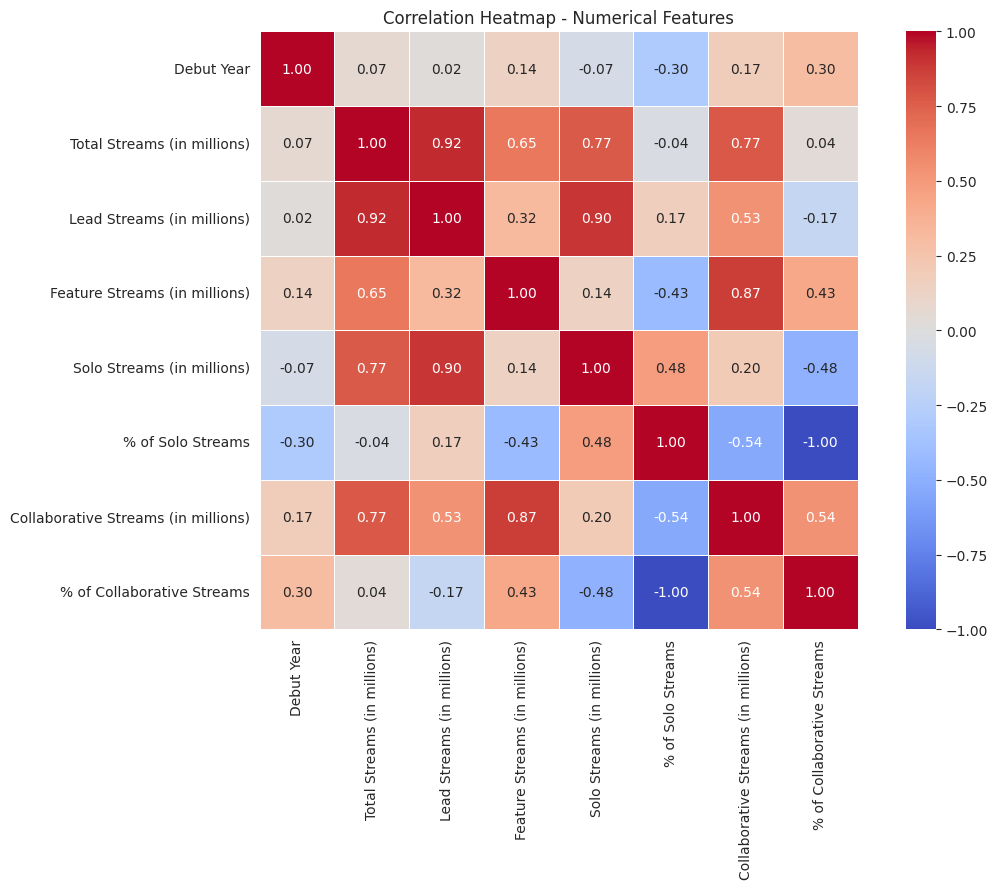


EDA completed successfully!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

sns.set_style("whitegrid")

# ============================================================
# 1. LOAD DATASET
# ============================================================

CSV_PATH = "Most Streamed Artists on Spotify.csv"

df = pd.read_csv(CSV_PATH)

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())


# ============================================================
# 2. NUMERICAL COLUMNS
# ============================================================

num_cols = [
    'Debut Year',
    'Total Streams (in millions)',
    'Lead Streams (in millions)',
    'Feature Streams (in millions)',
    'Solo Streams (in millions)',
    '% of Solo Streams',
    'Collaborative Streams (in millions)',
    '% of Collaborative Streams'
]


# ============================================================
# 3. MISSINGNESS HEATMAP
# ============================================================

fig1 = plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis",
    yticklabels=False
)

plt.title("Missingness Heatmap - Spotify Artists Dataset")
plt.xlabel("Columns")
plt.tight_layout()
plt.show()


# ============================================================
# 4. HISTOGRAMS
# ============================================================

fig2, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, col in enumerate(num_cols):

    row, colpos = divmod(i, 4)

    sns.histplot(
        df[col].dropna(),
        bins=30,
        kde=True,
        ax=axes[row, colpos],
        color='steelblue'
    )

    axes[row, colpos].set_title(f'Distribution of {col}')
    axes[row, colpos].set_xlabel(col)
    axes[row, colpos].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# 5. BOXPLOTS
# ============================================================

fig3, axes3 = plt.subplots(2, 4, figsize=(18, 9))

for i, col in enumerate(num_cols):

    row, colpos = divmod(i, 4)

    sns.boxplot(
        y=df[col],
        ax=axes3[row, colpos],
        color='lightcoral'
    )

    axes3[row, colpos].set_title(f'Boxplot of {col}')
    axes3[row, colpos].set_ylabel(col)

plt.tight_layout()
plt.show()


# ============================================================
# 6. CORRELATION HEATMAP
# ============================================================

fig4 = plt.figure(figsize=(12, 9))

numeric_df = df.select_dtypes(
    include=['int64', 'float64']
)

corr_matrix = numeric_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5
)

plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.show()


# ============================================================
# 7. OPTIONAL: SAVE ALL GRAPHS TO PDF
# ============================================================

# pdf = PdfPages('Spotify_EDA_Report.pdf')

# pdf.savefig(fig1)
# pdf.savefig(fig2)
# pdf.savefig(fig3)
# pdf.savefig(fig4)

# pdf.close()

print("\nEDA completed successfully!")